# Responsible AI Lab — Inside the Black Box with Neuronpedia

In the saliency maps notebook, you used **post-hoc** methods to highlight which input pixels mattered. But saliency maps treat the model as a black box — they don't tell you *what* the model has learned inside.

This notebook takes you **inside** a language model using [Neuronpedia](https://www.neuronpedia.org), an open platform for **mechanistic interpretability** research. You'll:

1. **Explore real SAE features** — individual "concepts" discovered inside GPT-2
2. **Search** for features by concept (e.g. "city names", "code syntax")
3. **Analyse** activation patterns, top logits, and feature explanations
4. **Compare** features across layers — from syntax to semantics
5. **Interactively test** features on your own text via embedded dashboards
6. **Steer** model behaviour via the Neuronpedia web interface

| Theme | What you'll do here |
|---|---|
| **Mechanistic Interpretability** | Explore real SAE features — concepts the model has learned |
| **Trustworthiness** | Judge whether auto-generated feature explanations are accurate |
| **Human-in-the-Loop** | Evaluate automated interpretability — where do humans add value? |

> **Requirements:** Internet connection. All exercises use the Neuronpedia public API (no key needed).

## Part 0: Setup

In [7]:
# Install required libraries (most are pre-installed in Colab)
!pip install -q requests numpy matplotlib
print("All packages installed ✓")

All packages installed ✓


In [8]:
import requests
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import IFrame, HTML, display

%matplotlib inline

# ---- Neuronpedia API helpers ----
BASE_URL = "https://www.neuronpedia.org/api"
MODEL_ID = "gpt2-small"
SAE_SET = "res-jb"
NUM_LAYERS = 12

def np_get_feature(model_id, source, index):
    """GET a feature's full data: explanations, activations, logits."""
    url = f"{BASE_URL}/feature/{model_id}/{source}/{index}"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    return resp.json()

def np_search_explanations(query, model_id=None, offset=0):
    """Search for features by concept description (semantic search)."""
    if model_id:
        url = f"{BASE_URL}/explanation/search-model"
        payload = {"modelId": model_id, "query": query, "offset": offset}
    else:
        url = f"{BASE_URL}/explanation/search-all"
        payload = {"query": query, "offset": offset}
    resp = requests.post(url, json=payload, timeout=30)
    resp.raise_for_status()
    return resp.json()

def feature_url(model_id, source, index):
    return f"https://www.neuronpedia.org/{model_id}/{source}/{index}"

def embed_feature(model_id, source, index, width=800, height=600):
    """Embed an interactive Neuronpedia dashboard in the notebook."""
    url = f"https://neuronpedia.org/{model_id}/{source}/{index}?embed=true&embedexplanation=true&embedplots=true&embedtest=true"
    display(IFrame(src=url, width=width, height=height))

# Test the API
test = requests.get(f"{BASE_URL}/feature/{MODEL_ID}/6-res-jb/0", timeout=15)
print(f"API connection: {'OK ✓' if test.status_code == 200 else 'FAILED ✗'}")
print(f"Model: {MODEL_ID} (GPT-2 Small, 12 layers, 768-dim residual stream)")
print(f"SAE Set: {SAE_SET} (Joseph Bloom's residual stream SAEs, ~16K features per layer)")

API connection: OK ✓
Model: gpt2-small (GPT-2 Small, 12 layers, 768-dim residual stream)
SAE Set: res-jb (Joseph Bloom's residual stream SAEs, ~16K features per layer)


## Part 1: What Are Sparse Autoencoders (SAEs)?

Neural networks learn **distributed representations** — each neuron participates in many concepts, and each concept is spread across many neurons. This is called **superposition**, and it makes individual neurons nearly impossible to interpret.

**Sparse Autoencoders** disentangle these representations:

```
Activation vector (768-dim) → Encoder → Sparse features (~16K-dim, mostly zeros) → Decoder → Reconstructed activation
```

The few non-zero dimensions in the sparse representation are called **features**, and remarkably, many correspond to human-understandable concepts:
- *"Text about France"*
- *"The token 'the' at the start of a noun phrase"*
- *"Python variable names"*

[Joseph Bloom's SAEs](https://www.neuronpedia.org/gpt2-small) trained on GPT-2 Small discovered thousands of such features at each of its 12 layers. Neuronpedia hosts these features with:
- **Auto-generated explanations** (what does this feature detect?)
- **Top activating examples** (real text that triggers this feature)
- **Logit effects** (how does this feature influence the model's next-token predictions?)
- **Interactive testing** (try your own text!)

In [9]:
# Let's embed an interactive feature dashboard directly in the notebook.
# This feature was auto-explained as relating to personal names/titles.

print("Feature: gpt2-small / layer 8 / feature 5765")
print("Below: interactive Neuronpedia dashboard (you can test your own text!)")
print()
embed_feature(MODEL_ID, "8-res-jb", 5765)

Feature: gpt2-small / layer 8 / feature 5765
Below: interactive Neuronpedia dashboard (you can test your own text!)



## Part 2: Exploring Features Programmatically

Let's pull feature data via the API and analyse it. Each feature comes with:
- **Explanations**: auto-generated descriptions + confidence scores
- **Activations**: real text examples where this feature fires, with per-token activation values
- **Logits**: which output tokens this feature promotes or suppresses

In [10]:
# Fetch and display a feature's data
def show_feature(model_id, source, index):
    """Fetch a feature and display a rich summary."""
    data = np_get_feature(model_id, source, index)

    # Explanation
    explanations = data.get("explanations", [])
    top_exp = explanations[0] if explanations else {}
    desc = top_exp.get("description", "No explanation available")
    score = top_exp.get("score", None)

    print(f"Feature: {model_id}/{source}/{index}")
    print(f"URL: {feature_url(model_id, source, index)}")
    print(f"Explanation: {desc}")
    if score is not None:
        print(f"Explanation confidence score: {score}")
    print()

    # Activations summary
    activations = data.get("activations", [])
    print(f"Activation examples: {len(activations)}")
    if activations:
        # Collect all activation values across examples
        all_max_vals = []
        for act in activations:
            vals = act.get("values", [])
            if vals:
                all_max_vals.append(max(vals))
        if all_max_vals:
            print(f"  Max activation range: {min(all_max_vals):.2f} — {max(all_max_vals):.2f}")
    print()

    # Show top 3 activating examples with highlighted tokens
    print("Top activating examples:")
    print("-" * 60)
    for i, act in enumerate(activations[:3]):
        tokens = act.get("tokens", [])
        values = act.get("values", [])
        if not tokens or not values:
            continue
        max_val = max(values)
        # Build highlighted text
        parts = []
        for tok, val in zip(tokens, values):
            if val > max_val * 0.3:
                parts.append(f">>>{tok}<<<")
            else:
                parts.append(tok)
        text = "".join(parts)
        if len(text) > 150:
            text = text[:150] + "..."
        print(f"  [{i+1}] {text}")
    print()

    return data

# Let's look at features from different layers
data_l0 = show_feature(MODEL_ID, "0-res-jb", 9408)
print("=" * 60)
print()
time.sleep(0.5)
data_l6 = show_feature(MODEL_ID, "6-res-jb", 2835)
print("=" * 60)
print()
time.sleep(0.5)
data_l11 = show_feature(MODEL_ID, "11-res-jb", 3258)

Feature: gpt2-small/0-res-jb/9408
URL: https://www.neuronpedia.org/gpt2-small/0-res-jb/9408
Explanation: values and beliefs-related phrases

Activation examples: 59
  Max activation range: 0.00 — 1.62

Top activating examples:
------------------------------------------------------------
  [1] ender of Israel" award from the World>>> Values<<< Network at the Third Annual Champions of Jewish
  [2]  at Davis, whose team used the World>>> Values<<< Survey to show larger cultural than genetic differences
  [3]  Iron 4.3% * Percent Daily>>> Values<<< are based on a 2000 calorie diet.


Feature: gpt2-small/6-res-jb/2835
URL: https://www.neuronpedia.org/gpt2-small/6-res-jb/2835
Explanation: descriptions or mentions of traffic directions or locations

Activation examples: 67
  Max activation range: 0.00 — 48.61

Top activating examples:
------------------------------------------------------------
  [1]  blocked all four lanes Friday morning of south>>>bound<<< I-75 near Mack in Detroit.
  [2]  

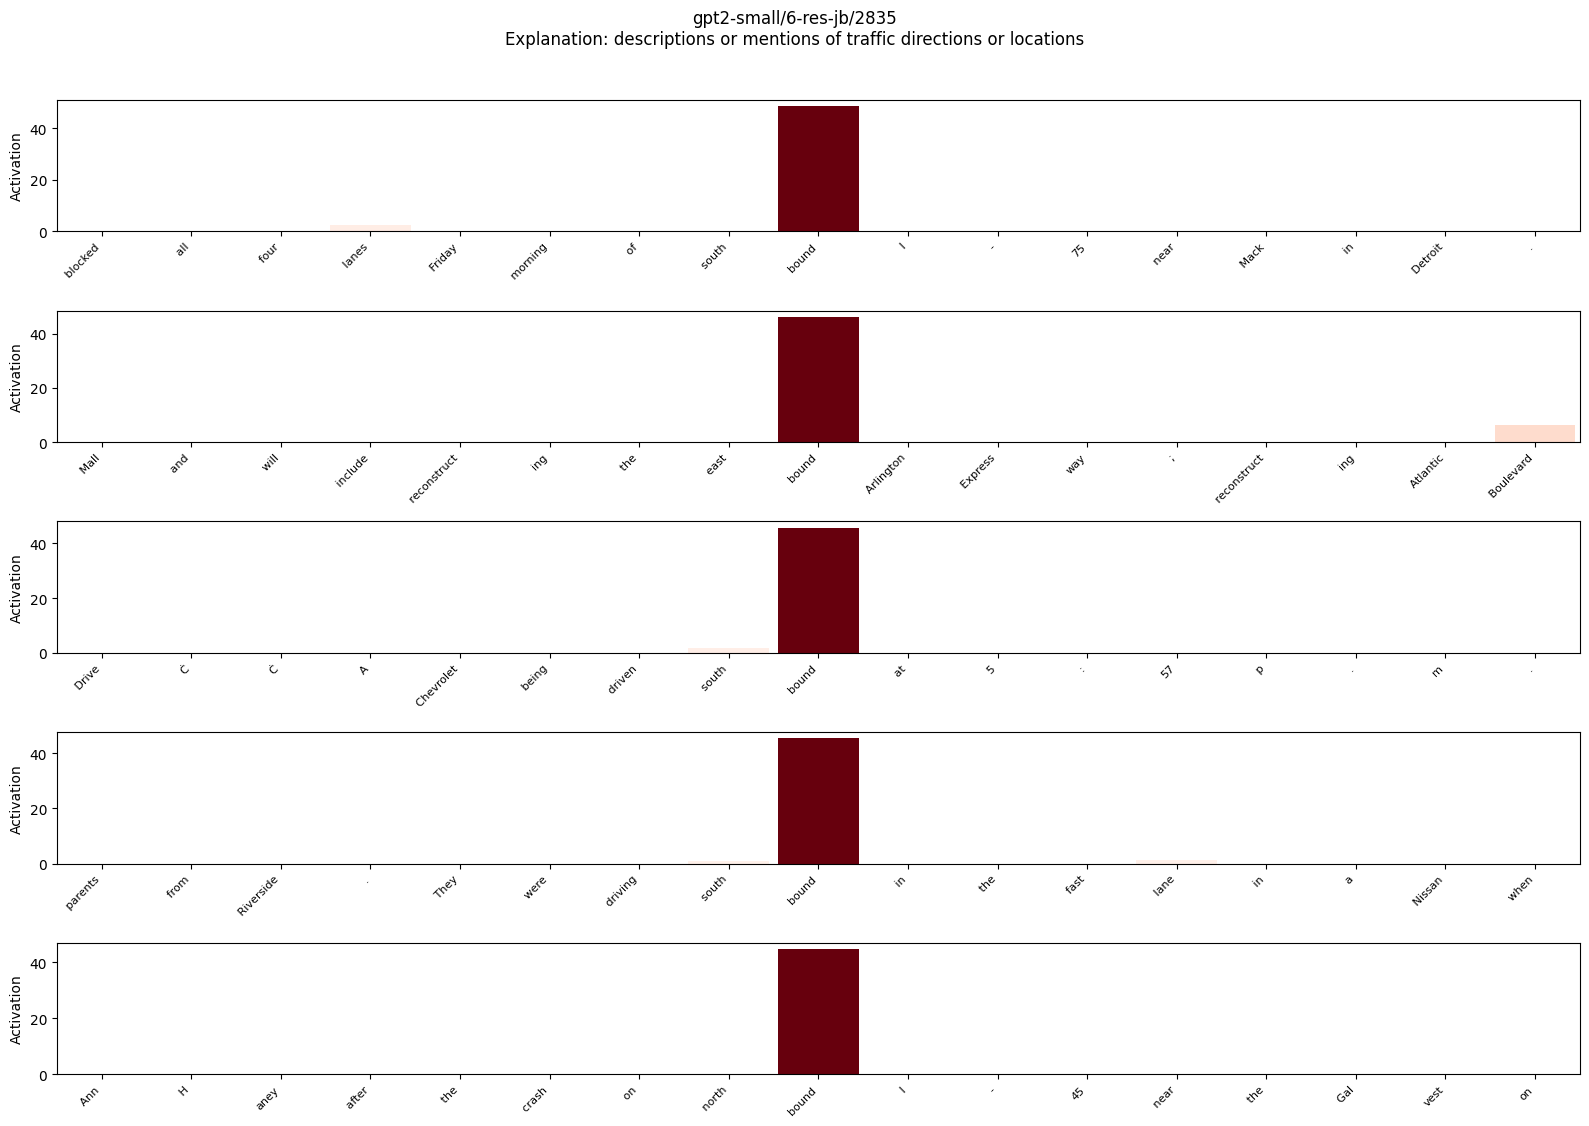

In [11]:
# Visualize activation patterns for a feature
def plot_feature_activations(data, title="Feature Activations"):
    """Plot activation bar charts for a feature's top examples."""
    activations = data.get("activations", [])
    if not activations:
        print("No activation data available.")
        return

    # Take top 5 examples
    examples = activations[:5]
    fig, axes = plt.subplots(len(examples), 1, figsize=(16, 2.2 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for ax, act in zip(axes, examples):
        tokens = act.get("tokens", [])
        values = act.get("values", [])
        if not tokens or not values:
            continue

        # Truncate if too many tokens
        max_tokens = 40
        if len(tokens) > max_tokens:
            # Find the peak and center around it
            peak_idx = np.argmax(values)
            start = max(0, peak_idx - max_tokens // 2)
            end = min(len(tokens), start + max_tokens)
            tokens = tokens[start:end]
            values = values[start:end]

        # Create bar chart colored by activation strength
        max_val = max(max(values), 0.01)
        norm = plt.Normalize(vmin=0, vmax=max_val)
        cmap = plt.cm.Reds
        colors = [cmap(norm(v)) for v in values]

        ax.bar(range(len(tokens)), values, color=colors, width=0.9)
        ax.set_xticks(range(len(tokens)))
        ax.set_xticklabels(tokens, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel("Activation")
        ax.set_xlim(-0.5, len(tokens) - 0.5)

    explanations = data.get("explanations", [])
    desc = explanations[0]["description"] if explanations else "?"
    plt.suptitle(f"{title}\nExplanation: {desc}", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

# Visualize the layer 6 feature
plot_feature_activations(data_l6, title=f"{MODEL_ID}/6-res-jb/2835")

In [12]:
# Analyse a feature's logit effects: what tokens does it promote/suppress?
def show_logit_effects(data):
    """Display the top positive and negative logit effects."""
    explanations = data.get("explanations", [])
    desc = explanations[0]["description"] if explanations else "?"

    print(f"Logit effects for feature (explanation: {desc})")
    print()

    # The Neuronpedia API doesn't include logit data in the GET response.
    # Logit effects are computed and displayed in the interactive dashboard.
    # We'll show the feature via an embedded IFrame instead.
    model_id = data.get("modelId", MODEL_ID)
    layer = data.get("layer", "")
    index = data.get("index", "")

    print("Logit effects are available on the interactive Neuronpedia dashboard.")
    print(f"URL: {feature_url(model_id, layer, index)}")
    print()
    print("Embedding feature dashboard (scroll down to see logit effects):")
    embed_feature(model_id, layer, index)

show_logit_effects(data_l6)


Logit effects for feature (explanation: descriptions or mentions of traffic directions or locations)

Logit effects are available on the interactive Neuronpedia dashboard.
URL: https://www.neuronpedia.org/gpt2-small/6-res-jb/2835

Embedding feature dashboard (scroll down to see logit effects):


### From Neurons to Features

What you've just seen is the core insight of **mechanistic interpretability**: individual neurons are often **polysemantic** (they respond to many unrelated things), but SAE features can isolate **monosemantic** concepts.

However, important questions remain:
- **Completeness**: SAEs don't capture everything — some information is lost in the "reconstruction error"
- **Faithfulness**: Does the auto-generated explanation truly describe what triggers the feature?
- **Causality**: A feature that *correlates* with a concept might not *cause* the model's behaviour

Researchers use techniques like **ablation studies**, **activation patching**, and **circuit analysis** to validate features.

## Part 3: Search for Features by Concept

Neuronpedia lets you search for features by their description. This is like asking: "does this model have a feature for ___?"

The search uses **semantic similarity** between your query and the auto-generated feature explanations, so you can use natural language.

In [13]:
# Search for features related to a concept
def search_and_display(query, model_id=None, n=10):
    """Search for features by concept and display results."""
    try:
        result = np_search_explanations(query, model_id=model_id)
        features = result.get("results", [])
        total = result.get("resultsCount", len(features))

        print(f"Search: \"{query}\"" + (f"  (model: {model_id})" if model_id else "  (all models)"))
        print(f"Found: {total} results")
        print("-" * 80)

        for i, f in enumerate(features[:n]):
            m = f.get("modelId", "?")
            layer = f.get("layer", "?")
            idx = f.get("index", "?")
            desc = f.get("description", "")
            sim = f.get("cosine_similarity", None)
            sim_str = f" (similarity: {sim:.3f})" if sim is not None else ""

            print(f"  #{i+1}: {m}/{layer}/{idx}")
            print(f"       {desc}{sim_str}")
            print(f"       → {feature_url(m, layer, idx)}")
            print()

        return features
    except Exception as e:
        print(f"Search error: {e}")
        return []

# Search for some interesting concepts
results_cities = search_and_display("city names and geographical locations", model_id=MODEL_ID)

Search: "city names and geographical locations"  (model: gpt2-small)
Found: 20 results
--------------------------------------------------------------------------------
  #1: gpt2-small/8-att-kk/68
       city names and geographical locations (similarity: 1.000)
       → https://www.neuronpedia.org/gpt2-small/8-att-kk/68

  #2: gpt2-small/9-res_mid_128k-oai/37489
        city names and geographical locations (similarity: 0.974)
       → https://www.neuronpedia.org/gpt2-small/9-res_mid_128k-oai/37489

  #3: gpt2-small/6-res_post_32k-oai/15896
        city names and geographic locations (similarity: 0.946)
       → https://www.neuronpedia.org/gpt2-small/6-res_post_32k-oai/15896

  #4: gpt2-small/11-res_post_128k-oai/116480
        city names and geographic locations (similarity: 0.946)
       → https://www.neuronpedia.org/gpt2-small/11-res_post_128k-oai/116480

  #5: gpt2-small/8-att_128k-oai/88035
       city names and related geographical locations (similarity: 0.945)
       → https://w

In [14]:
# Search for different types of concepts
print("=" * 80)
results_code = search_and_display("Python programming code syntax", model_id=MODEL_ID)
print("\n" + "=" * 80)
results_emotion = search_and_display("emotional sentiment positive negative", model_id=MODEL_ID)
print("\n" + "=" * 80)
results_math = search_and_display("mathematical expressions and numbers", model_id=MODEL_ID)

Search: "Python programming code syntax"  (model: gpt2-small)
Found: 20 results
--------------------------------------------------------------------------------
  #1: gpt2-small/8-res_fs24576-jb/20150
       Python programming code snippets (similarity: 0.776)
       → https://www.neuronpedia.org/gpt2-small/8-res_fs24576-jb/20150

  #2: gpt2-small/10-res_scl-ajt/5038
        Python programming syntax elements and constructs (similarity: 0.730)
       → https://www.neuronpedia.org/gpt2-small/10-res_scl-ajt/5038

  #3: gpt2-small/8-res_fs6144-jb/1040
       Python code snippets and related syntax elements (similarity: 0.710)
       → https://www.neuronpedia.org/gpt2-small/8-res_fs6144-jb/1040

  #4: gpt2-small/3-att_128k-oai/56383
        programming syntax and formatting in code (similarity: 0.708)
       → https://www.neuronpedia.org/gpt2-small/3-att_128k-oai/56383

  #5: gpt2-small/11-res_post_128k-oai/42466
        instances of Python programming syntax and related functions (similar

In [15]:
# YOUR TURN: Search for concepts you're interested in!
# Change the query below and re-run

your_query = "French wines"  # <-- change this!
# Try: "medical terminology", "legal language", "music and instruments",
#      "food and cooking", "weather and climate", "historical events"

your_results = search_and_display(your_query, model_id=MODEL_ID)

Search: "French wines"  (model: gpt2-small)
Found: 20 results
--------------------------------------------------------------------------------
  #1: gpt2-small/2-res_post_128k-oai/50627
       references to French wines (similarity: 0.758)
       → https://www.neuronpedia.org/gpt2-small/2-res_post_128k-oai/50627

  #2: gpt2-small/0-mlp_128k-oai/129627
       mentions of wines (similarity: 0.638)
       → https://www.neuronpedia.org/gpt2-small/0-mlp_128k-oai/129627

  #3: gpt2-small/9-mlp_128k-oai/69174
        references to specific types of wines or related products (similarity: 0.620)
       → https://www.neuronpedia.org/gpt2-small/9-mlp_128k-oai/69174

  #4: gpt2-small/10-res_post_32k-oai/17253
        references to wine and related products (similarity: 0.609)
       → https://www.neuronpedia.org/gpt2-small/10-res_post_32k-oai/17253

  #5: gpt2-small/1-att_128k-oai/401
        references to wine and related products (similarity: 0.609)
       → https://www.neuronpedia.org/gpt2-smal

Fetching full data for: gpt2-small/8-att-kk/68

Feature: gpt2-small/8-att-kk/68
URL: https://www.neuronpedia.org/gpt2-small/8-att-kk/68
Explanation: city names and geographical locations

Activation examples: 36
  Max activation range: 0.00 — 2.79

Top activating examples:
------------------------------------------------------------
  [1] <|endoftext|>. 7, 2012, in>>> San<<<>>> Francisco<<< Photo by Justin Sullivan/Getty Images.ĊĊItâĢĻs going to be one blockbuster of a history-making ye...
  [2] <|endoftext|>. 7, 2012, in>>> San<<<>>> Francisco<<< Photo by Justin Sullivan/Getty Images.ĊĊItâĢĻs going to be one blockbuster of a history-making ye...
  [3] <|endoftext|>. 7, 2012, in>>> San<<<>>> Francisco<<< Photo by Justin Sullivan/Getty Images.ĊĊItâĢĻs going to be one blockbuster of a history-making ye...



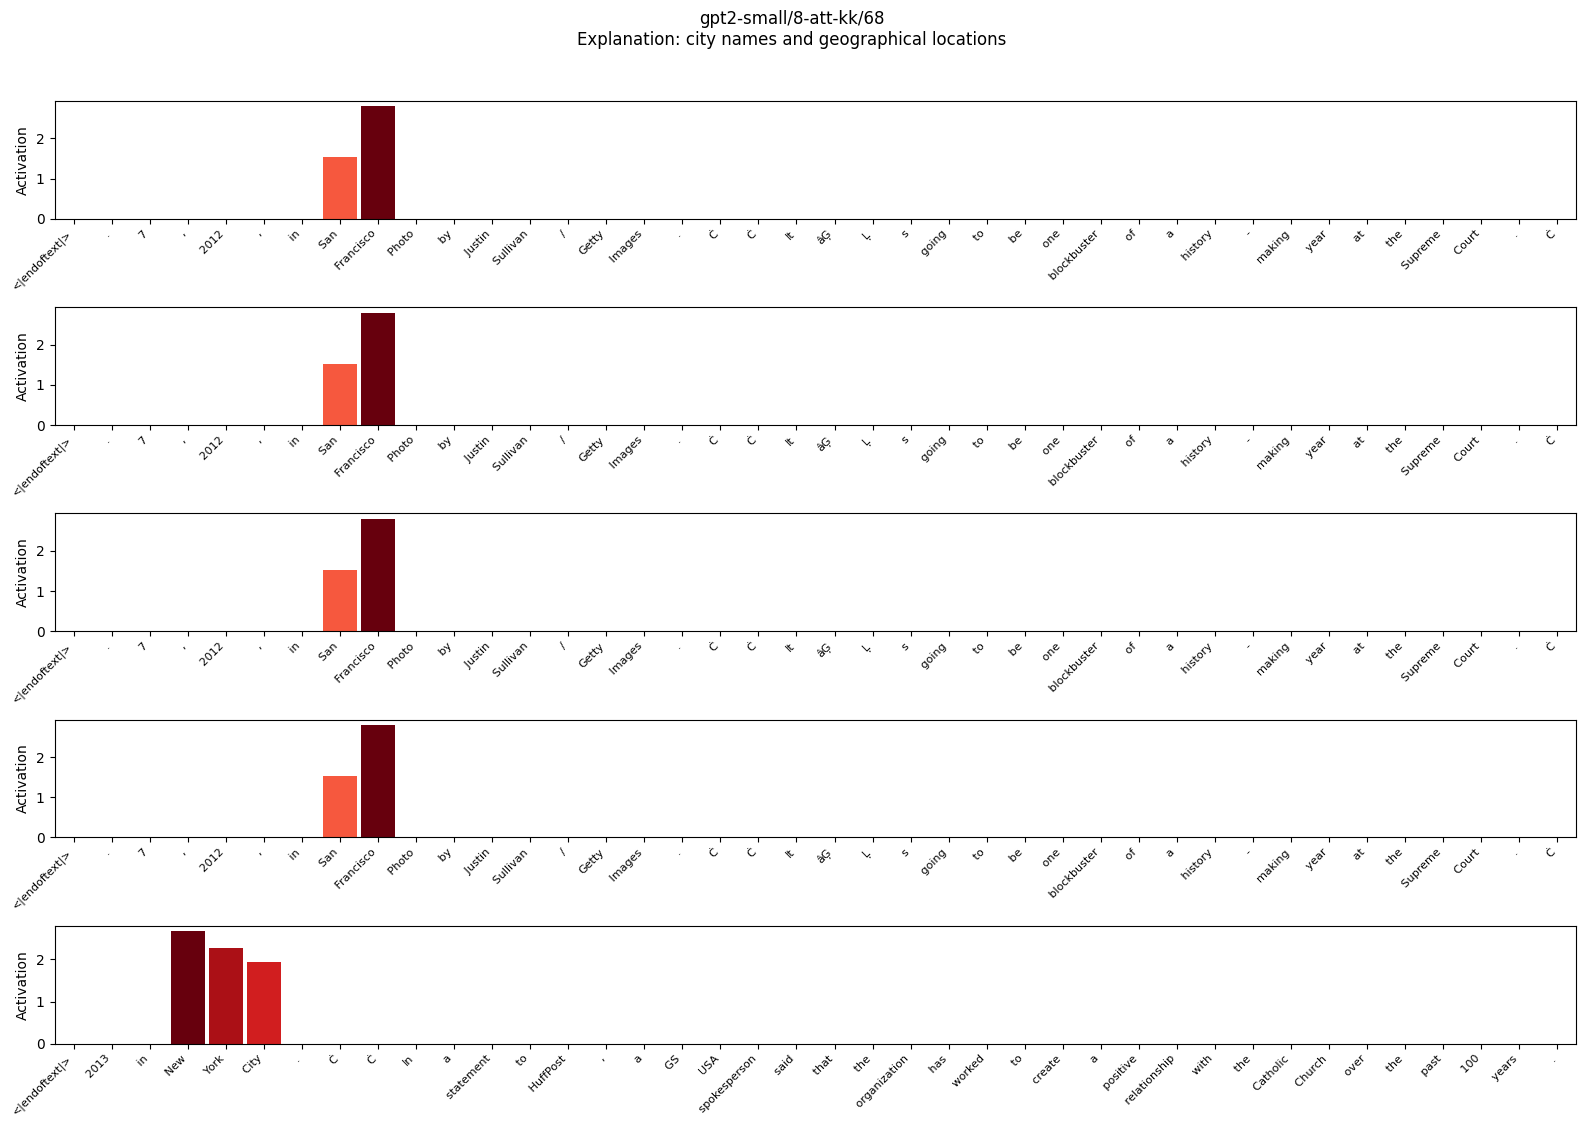

In [16]:
# Deep dive: pick a feature from search results and explore it

# Let's take the first result from the city search and fetch its full data
if results_cities:
    first = results_cities[0]
    m_id = first.get("modelId", MODEL_ID)
    layer = first.get("layer", "6-res-jb")
    idx = first.get("index", "0")

    print(f"Fetching full data for: {m_id}/{layer}/{idx}")
    print()

    try:
        full_data = np_get_feature(m_id, layer, idx)
        show_feature(m_id, layer, idx)
        plot_feature_activations(full_data, title=f"{m_id}/{layer}/{idx}")
    except Exception as e:
        print(f"Error fetching feature: {e}")
        print(f"View it on Neuronpedia: {feature_url(m_id, layer, idx)}")
else:
    print("No city search results available. Try searching for a different concept.")

## Part 4: Interactive Feature Testing

Each Neuronpedia feature dashboard includes a **Test** panel where you can type any text and see how strongly the feature activates on each token. This is the mechanistic interpretability equivalent of a **scientific experiment**.

**Workflow:**
1. Read the feature's auto-explanation
2. Form a **hypothesis** about what the feature detects
3. Type text into the test panel that **should** activate it
4. Type text that **should not** activate it
5. Check: does the feature behave as expected?

In [17]:
# Embed several features for interactive testing
# Try typing your own text in the "Test" panel of each dashboard!

test_features = [
    ("6-res-jb", 2835, "Feature A — read its explanation, then test your hypothesis"),
    ("8-res-jb", 5765, "Feature B — what does this one detect?"),
    ("11-res-jb", 3258, "Feature C — compare with the others"),
]

for source, idx, label in test_features:
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"Feature: {MODEL_ID}/{source}/{idx}")
    print(f"{'='*60}")

    try:
        data = np_get_feature(MODEL_ID, source, idx)
        exps = data.get("explanations", [])
        desc = exps[0]["description"] if exps else "No explanation"
        print(f"Auto-explanation: {desc}")
        print()
        print(">> Use the dashboard below to TEST this feature on your own text.")
        print(">> Does the activation pattern match the explanation?")
    except:
        pass

    embed_feature(MODEL_ID, source, idx, height=500)
    print()


Feature A — read its explanation, then test your hypothesis
Feature: gpt2-small/6-res-jb/2835
Auto-explanation: descriptions or mentions of traffic directions or locations

>> Use the dashboard below to TEST this feature on your own text.
>> Does the activation pattern match the explanation?




Feature B — what does this one detect?
Feature: gpt2-small/8-res-jb/5765
Auto-explanation: keywords related to personal names and titles, especially when used in formal contexts

>> Use the dashboard below to TEST this feature on your own text.
>> Does the activation pattern match the explanation?




Feature C — compare with the others
Feature: gpt2-small/11-res-jb/3258
Auto-explanation: numbers

>> Use the dashboard below to TEST this feature on your own text.
>> Does the activation pattern match the explanation?


In [19]:
# Exercise: Evaluate the auto-explanations
# For each feature above, rate the explanation on a 1-5 scale:
#   1 = completely wrong
#   2 = vaguely related but misleading
#   3 = partially correct
#   4 = mostly correct, minor issues
#   5 = excellent, matches activation pattern perfectly

# Fill in your ratings:
ratings = {
    "Feature A (6-res-jb/2835)": 4,   # <-- your rating (1-5)
    "Feature B (8-res-jb/5765)": 3,    # <-- your rating (1-5)
    "Feature C (11-res-jb/3258)": 1,   # <-- your rating (1-5)
}

print("Your explanation quality ratings:")
for feat, rating in ratings.items():
    stars = "★" * rating + "☆" * (5 - rating) if rating > 0 else "(not rated)"
    print(f"  {feat}: {stars}")

print()
print("DISCUSSION:")
print("  1. Did any explanation surprise you after testing?")
print("  2. What would you change about the explanation?")
print("  3. How would you design a BETTER auto-explanation system?")
print("  4. Is a 'correct' explanation always useful? What makes an explanation actionable?")

Your explanation quality ratings:
  Feature A (6-res-jb/2835): ★★★★☆
  Feature B (8-res-jb/5765): ★★★☆☆
  Feature C (11-res-jb/3258): ★☆☆☆☆

DISCUSSION:
  1. Did any explanation surprise you after testing?
  2. What would you change about the explanation?
  3. How would you design a BETTER auto-explanation system?
  4. Is a 'correct' explanation always useful? What makes an explanation actionable?


### Automated Interpretability — Humans in the Loop

The explanations you just evaluated were generated by **auto-interp**: an automated pipeline that shows GPT-4 the top activating examples and asks it to describe the pattern.

This is itself a **human-in-the-loop** problem:
- **Auto-interp** is fast and scalable — it can explain millions of features
- **Humans** catch subtleties and errors that LLMs miss
- The **quality ratings** you just gave are exactly how researchers evaluate auto-interp systems

Key questions:
- Can we build reliable auto-interp at scale, or will it always need human oversight?
- What's the right balance between speed (automated) and accuracy (human)?
- If we can't explain every feature, which ones matter most?

## Part 5: Features Across Layers — A Hierarchy of Abstraction

Neural networks process information through successive layers. In GPT-2:
- **Early layers (0-3)**: token identity, simple syntax, position information
- **Middle layers (4-7)**: entities, topics, semantic relationships
- **Late layers (8-11)**: abstract reasoning, prediction targets, task features

Let's verify this by fetching features from different layers and comparing them.

In [20]:
# Fetch multiple features per layer and summarise their explanations
layer_features = {
    0: [100, 500, 1000, 2000, 5000, 8000, 12000],
    3: [100, 500, 1000, 2000, 5000, 8000, 12000],
    6: [100, 500, 1000, 2000, 5000, 8000, 12000],
    9: [100, 500, 1000, 2000, 5000, 8000, 12000],
    11: [100, 500, 1000, 2000, 5000, 8000, 12000],
}

print("Sampling features from different layers...")
print("(Fetching explanations to see what each layer learns)")
print()

layer_explanations = {}
for layer, indices in layer_features.items():
    source = f"{layer}-res-jb"
    explanations = []
    for idx in indices:
        try:
            data = np_get_feature(MODEL_ID, source, idx)
            exps = data.get("explanations", [])
            if exps:
                explanations.append(exps[0]["description"])
            time.sleep(0.3)
        except:
            continue
    layer_explanations[layer] = explanations

    print(f"Layer {layer:2d} features:")
    for exp in explanations[:5]:
        print(f"  • {exp[:80]}")
    print()

print(">> Compare the explanations across layers:")
print(">> Do early layers focus on simpler patterns?")
print(">> Do later layers capture more abstract concepts?")

Sampling features from different layers...
(Fetching explanations to see what each layer learns)

Layer  0 features:
  • phrases related to providing guidance or instructions
  • references to different versions of the Windows operating system
  • terms related to the legalization of marijuana, specifically focusing on the wor
  • proper nouns of various geographic locations, specifically islands
  • mentions of spouses or partners, specifically focusing on actions or relationshi

Layer  3 features:
  • references to legal, political, and financial contexts
  • mentions of something being held in high regard or considered special or holy
  • words related to dining events or meals
  • instances of the word "junior"
  • locations or settings described as significant, notable, or special

Layer  6 features:
  • phrases related to causes and effects
  • mentions of friends or acquaintances
  • references or mentions of the word "Ad"
  • words related to different card games
  • phrases re

Feature activation statistics by layer
Layer    Avg Max Act     Avg # Active Tokens    # Examples
----------------------------------------------------------------------
  0      2.35            1.1                    20
  3      40.01           1.1                    20
  6      16.18           1.5                    20
  9      20.68           5.5                    20
  11     55.82           1.6                    20


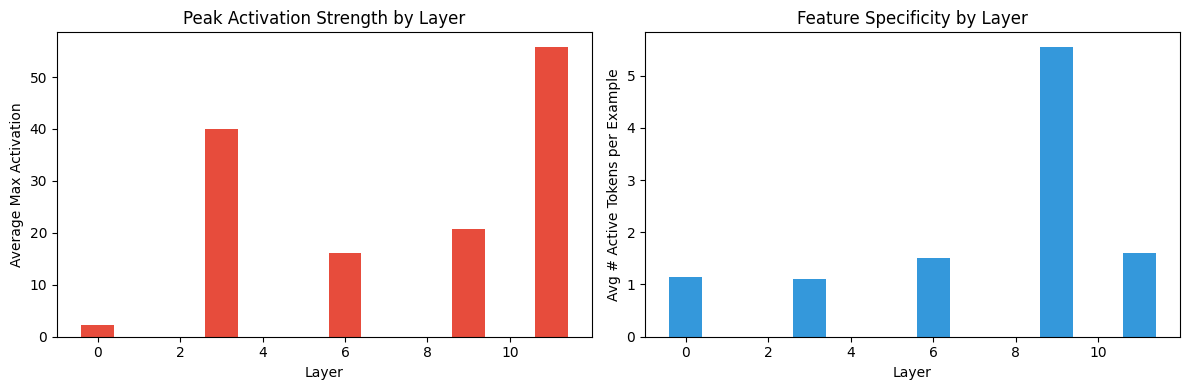


>> More specific features (fewer active tokens) tend to be more interpretable.
>> How does specificity change with depth?


In [21]:
# Quantitative analysis: feature activation statistics across layers

print("Feature activation statistics by layer")
print("=" * 70)
print(f"{'Layer':<8} {'Avg Max Act':<15} {'Avg # Active Tokens':<22} {'# Examples'}")
print("-" * 70)

layer_stats = {}
for layer in [0, 3, 6, 9, 11]:
    source = f"{layer}-res-jb"
    # Sample a few features per layer
    max_acts = []
    active_counts = []

    for idx in [500, 2000, 5000, 10000]:
        try:
            data = np_get_feature(MODEL_ID, source, idx)
            activations = data.get("activations", [])
            for act in activations[:5]:
                vals = act.get("values", [])
                if vals:
                    max_acts.append(max(vals))
                    active_counts.append(sum(1 for v in vals if v > 0.1))
            time.sleep(0.2)
        except:
            continue

    if max_acts:
        layer_stats[layer] = {
            "avg_max": np.mean(max_acts),
            "avg_active": np.mean(active_counts),
            "n": len(max_acts)
        }
        print(f"  {layer:<6d} {np.mean(max_acts):<15.2f} {np.mean(active_counts):<22.1f} {len(max_acts)}")

# Plot
if layer_stats:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    layers = sorted(layer_stats.keys())
    avg_max = [layer_stats[l]["avg_max"] for l in layers]
    avg_active = [layer_stats[l]["avg_active"] for l in layers]

    axes[0].bar(layers, avg_max, color='#e74c3c', width=0.8)
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Average Max Activation")
    axes[0].set_title("Peak Activation Strength by Layer")

    axes[1].bar(layers, avg_active, color='#3498db', width=0.8)
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Avg # Active Tokens per Example")
    axes[1].set_title("Feature Specificity by Layer")

    plt.tight_layout()
    plt.show()

    print("\n>> More specific features (fewer active tokens) tend to be more interpretable.")
    print(">> How does specificity change with depth?")

## Part 6: Steering Model Behaviour

The most dramatic application of mechanistic interpretability is **steering**: if we've identified a feature representing a concept, we can **amplify** it during generation and watch the model's output shift.

This is the principle behind [Anthropic's Golden Gate Claude](https://www.anthropic.com/news/golden-gate-claude) — but you can do it with any feature.

**Try it yourself** at: [neuronpedia.org/steer](https://www.neuronpedia.org/steer)

The embedded dashboard below lets you steer GPT-2 Small interactively:

In [22]:
# Embed the Neuronpedia steering interface
print("Neuronpedia Steering Interface")
print("=" * 50)
print("1. Enter a prompt (e.g., 'Once upon a time')")
print("2. Add a feature to steer with (use one you found in Part 3!)")
print("3. Adjust the strength slider")
print("4. Compare 'Default' vs 'Steered' output")
print()

display(IFrame(
    src="https://neuronpedia.org/steer?modelId=gpt2-small",
    width=800, height=700
))

Neuronpedia Steering Interface
1. Enter a prompt (e.g., 'Once upon a time')
2. Add a feature to steer with (use one you found in Part 3!)
3. Adjust the strength slider
4. Compare 'Default' vs 'Steered' output



In [23]:
# Alternatively: find features to steer with based on your searches
print("Features you discovered that you could steer with:")
print("=" * 60)
print()

# Re-search for a few concepts and list steer-worthy features
steer_concepts = ["happiness and joy", "formal academic language", "science fiction"]
for concept in steer_concepts:
    try:
        result = np_search_explanations(concept, model_id=MODEL_ID)
        features = result.get("results", [])
        if features:
            f = features[0]
            m = f.get("modelId", "?")
            layer = f.get("layer", "?")
            idx = f.get("index", "?")
            desc = f.get("description", "")
            print(f"  Concept: '{concept}'")
            print(f"    Feature: {m}/{layer}/{idx}")
            print(f"    Description: {desc[:60]}")
            print(f"    To steer: use model={m}, layer={layer}, index={idx}")
            print()
        time.sleep(0.5)
    except Exception as e:
        print(f"  '{concept}': search error — {e}")

print(">> Copy these into the steering interface above!")
print(">> Try amplifying (positive strength) and suppressing (negative strength).")
print()
print("QUESTIONS:")
print("  1. How strong does steering need to be before output changes noticeably?")
print("  2. Does the output still make grammatical sense at high strength?")
print("  3. If a company steered their chatbot to always be positive,")
print("     should that be disclosed to users? Why or why not?")

Features you discovered that you could steer with:

  Concept: 'happiness and joy'
    Feature: gpt2-small/0-mlp_32k-oai/29563
    Description: expressions of happiness and joy
    To steer: use model=gpt2-small, layer=0-mlp_32k-oai, index=29563

  Concept: 'formal academic language'
    Feature: gpt2-small/10-att_32k-oai/22802
    Description: formal academic language and complex expressions
    To steer: use model=gpt2-small, layer=10-att_32k-oai, index=22802

  Concept: 'science fiction'
    Feature: gpt2-small/3-mlp_32k-oai/14362
    Description: mentions of science fiction
    To steer: use model=gpt2-small, layer=3-mlp_32k-oai, index=14362

>> Copy these into the steering interface above!
>> Try amplifying (positive strength) and suppressing (negative strength).

QUESTIONS:
  1. How strong does steering need to be before output changes noticeably?
  2. Does the output still make grammatical sense at high strength?
  3. If a company steered their chatbot to always be positive,
   

## Part 7: Do Different Models Learn Similar Features?

Neuronpedia hosts features from multiple models (GPT-2, Gemma, DeepSeek, etc.). An important research question: **do different models learn the same features?**

If they do, that suggests these features reflect something fundamental about language. If they don't, features may be artifacts of training.

In [24]:
# Search for the same concept across different models
concept = "references to time and dates"

print(f"Searching for '{concept}' across all models...")
print()

try:
    result = np_search_explanations(concept)
    features = result.get("results", [])

    # Group by model
    by_model = {}
    for f in features:
        m = f.get("modelId", "unknown")
        if m not in by_model:
            by_model[m] = []
        by_model[m].append(f)

    print(f"Found features in {len(by_model)} different models:")
    print("-" * 60)
    for model, feats in sorted(by_model.items()):
        print(f"\n  Model: {model}")
        for feat in feats[:2]:
            layer = feat.get("layer", "?")
            idx = feat.get("index", "?")
            desc = feat.get("description", "")
            print(f"    {layer}/{idx}: {desc[:60]}")

    print()
    print(">> Similar features across different models suggest these are")
    print(">> fundamental aspects of language that any sufficiently capable")
    print(">> model will learn to represent. This is called 'universality'.")

except Exception as e:
    print(f"Error: {e}")

Searching for 'references to time and dates' across all models...

Found features in 5 different models:
------------------------------------------------------------

  Model: gemma-2-2b
    14-gemmascope-res-16k/7031: references to time and dates
    12-gemmascope-res-1m/452262: references to time and dates

  Model: gemma-2-9b
    32-gemmascope-mlp-131k/7561: references to time and dates
    30-gemmascope-mlp-16k/5038: references to time and dates

  Model: gpt2-small
    9-res_post_32k-oai/8226: references to time and dates
    3-att_32k-oai/10090: references to time and dates

  Model: llama3.1-8b
    9-llamascope-mlp-131k/36750: references to time and dates
    9-llamascope-res-131k/73586: references to time and dates

  Model: pythia-70m-deduped
    3-mlp-sm/11984: references to time and dates

>> Similar features across different models suggest these are
>> fundamental aspects of language that any sufficiently capable
>> model will learn to represent. This is called 'universalit

### Can We Trust These Features?

You've explored dozens of features — but can we trust them? Several concerns apply:

1. **Completeness**: SAEs capture only part of the model's computation. Critical information may live in the reconstruction error.

2. **Faithfulness**: A feature described as "city names" might actually respond to something subtler. Auto-interp can be misleading — which is why **your human evaluation in Part 4 matters**.

3. **Causality vs. Correlation**: A feature that *correlates* with a concept may not *cause* the model's behaviour. Steering provides some causal evidence, but it's not conclusive.

4. **Superposition**: Models may pack more concepts than they have features. Even SAEs might not fully disentangle everything.

Important related concepts:
- **Ablation studies**: does removing a feature change behaviour as expected?
- **Circuit analysis**: how do features connect to form computational circuits?
- **The superposition hypothesis**: why models pack more features than neurons

**Reflection:** If you were auditing a model for bias, would SAE features be sufficient evidence? What additional analysis would you need?

## Discussion Questions

1. **You found features for concepts like "city names" and "emotions".** Does finding a feature mean we *understand* the model? What's the gap between feature discovery and genuine mechanistic understanding?

2. **Auto-interp explained each feature automatically, but some explanations were better than others.** What are the risks of trusting automated explanations? When should a human be in the loop?

3. **You saw that different models learn similar features.** Does this "universality" make you more or less confident that the features are meaningful?

4. **Steering can change model behaviour by amplifying features.** If companies could steer their AI systems using features, what governance frameworks would you want in place?

5. **SAE features are discovered, not designed.** Who should decide which features are "dangerous" (e.g., a feature for generating misinformation)? What should be done about them?

> These questions bridge interpretability and governance — two pillars of responsible AI.

Discussion

1. Feature discovery shows what the model responds to, but not why those representations arise. To achieve genuine mechanistic understanding, we would need to examine how these features emerge from the model’s weight structure and activation pathways, and whether perturbing those weights changes the discovered features. Therefore, identifying important features is only a first step; mechanistic interpretability requires understanding the causal processes that generate and use those features within the network. therefore, feature discovery is a path to genuine mechanistic interpretability, and gaps remain.

2. Automated explanations may not be reliable, and can sometimes be misleading or only partially accurate. If trusted blindly, they could lead to incorrect conclusions about how the model works. Therefore, humans should remain in the loop to critically evaluate these explanations, especially in safety-critical or high-stakes contexts.

3. The presence of similar features across different models increases confidence that these features capture meaningful patterns rather than artifacts of a single model. If multiple models independently learn the same features, it suggests that they reflect common structures in the data or in the task of language prediction. Even if these features do not perfectly align with human interpretations, their recurrence across models can still help us better understand latent space activations and how models internally represent information.

4. If companies can steer AI behaviour by amplifying certain features, governance frameworks should ensure that such capabilities are deployed ethically and transparently. AI systems should give primacy to user well-being rather than prioritising engagement optimisation, which often drives the commercialisation of chatbot systems. This principle is closely related to medical ethics. These standards may also need to be adapted to national contexts, as definitions of well-being and user protections can vary depending on constitutional and legal guarantees.

5. Since SAE features are discovered rather than designed, determining which features are potentially harmful should involve independent oversight. Decisions should not be made solely by the companies developing the models. Instead, independent review panels consisting of AI researchers, governance experts, policymakers, and public stakeholders should evaluate whether certain features pose risks, such as enabling misinformation or harmful manipulation. At the same time, governance should avoid excessive centralisation of power. Transparent and multi-stakeholder oversight mechanisms would help ensure that decisions about managing or suppressing dangerous features are accountable and balanced.


---

### Resources
- [Neuronpedia](https://www.neuronpedia.org) — explore features interactively
- [Anthropic: Scaling Monosemanticity](https://transformer-circuits.pub/2024/scaling-monosemanticity/) — SAE features at scale
- [Anthropic: Golden Gate Claude](https://www.anthropic.com/news/golden-gate-claude) — steering in production
- [SAELens](https://github.com/jbloomAus/SAELens) — train your own SAEs
- [ARENA Mechanistic Interpretability](https://www.arena.education/) — free course with exercises